In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import drive
drive.mount('/content/drive')
#Change Directory
%cd '/content/drive/MyDrive/IN2009B – SupplyChain'

#Read CVS files
df = pd.read_csv('IN2009B_PS_DatosInventarios.csv')
dfT = df[df['Planta'] == 'Tepic']
dfT = dfT.drop("Dia", axis=1)
products = {}
for product_id in dfT['Producto'].unique():
  products[product_id] = dfT[dfT['Producto'] == product_id]

Mounted at /content/drive
/content/drive/MyDrive/IN2009B – SupplyChain


In [5]:
#Filter by Product
Product_ID = list(products.keys())[2]
DpP = products[Product_ID]
DpP['Date'] = pd.date_range(start='2024-01-01', periods=len(DpP), freq='D')
description = DpP['DescrProducto'].iloc[5]
DpP.head()

<ipython-input-5-591a76f861cc>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DpP['Date'] = pd.date_range(start='2024-01-01', periods=len(DpP), freq='D')


,Planta,Producto,DescrProducto,Inventario,Abasto tránsito,Demanda,Date
2790,Tepic,10000920,Mortero 50k,279,50,0,2024-01-01
2791,Tepic,10000920,Mortero 50k,279,50,154,2024-01-02
2792,Tepic,10000920,Mortero 50k,175,155,129,2024-01-03
2793,Tepic,10000920,Mortero 50k,201,50,203,2024-01-04
2794,Tepic,10000920,Mortero 50k,148,88,103,2024-01-05


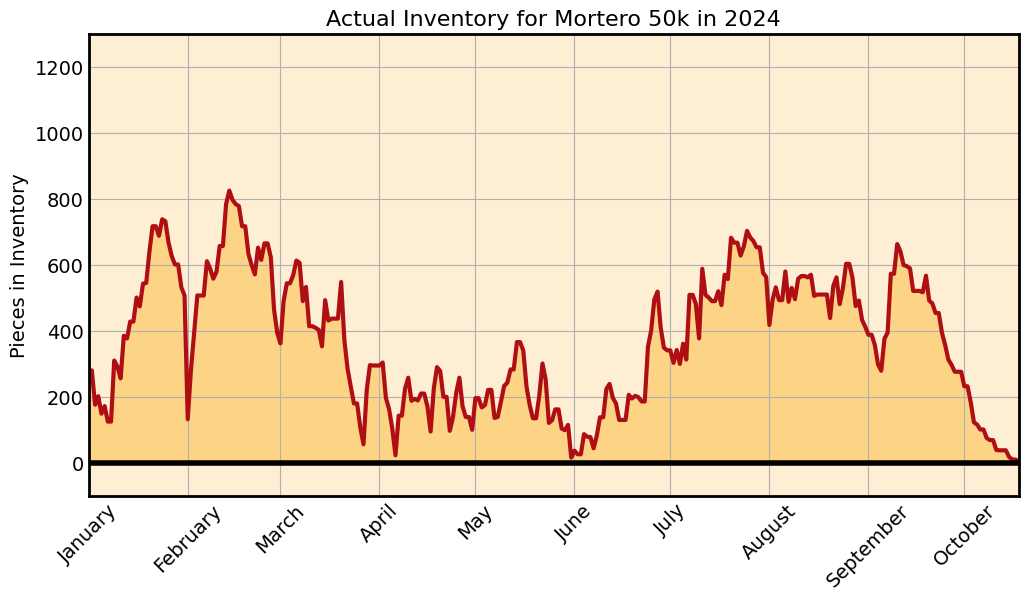

In [36]:
# prompt: change x limit of graph to only include date in "Date"

plt.figure(figsize=(12, 6))
plt.gca().set_facecolor('#feefd4') # Light orange background
plt.plot(DpP['Date'], DpP['Inventario'], color='#af0f14', linewidth=3) # Red thick line
plt.fill_between(DpP['Date'], DpP['Inventario'], color='#fdd486', alpha=1) # Orange fill
plt.axhline(y=0, color='black', linestyle='-', linewidth=4)

#plt.xlabel('Date', fontsize=14)
plt.ylabel('Pieces in Inventory', fontsize=14)
plt.title(f'Actual Inventory for {description} in 2024', fontsize=16)
plt.grid(True)
plt.ylim(-100,1300)
plt.xlim(DpP['Date'].min(), DpP['Date'].max()) # Set x-limit to the date range in the DataFrame
plt.xticks(rotation=45)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=14) # Increase tick label size
ax.xaxis.set_major_locator(mdates.MonthLocator()) # Set major ticks to every month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B')) # Format ticks as full month name
ax.tick_params(axis='both',        # apply to both axes
               which='both',       # apply to major *and* minor ticks
               length=0)
for spine in ax.spines.values():
    spine.set_linewidth(2)

plt.savefig(f'Actual_Inv_{description}.png', dpi=300, bbox_inches='tight')
plt.show()

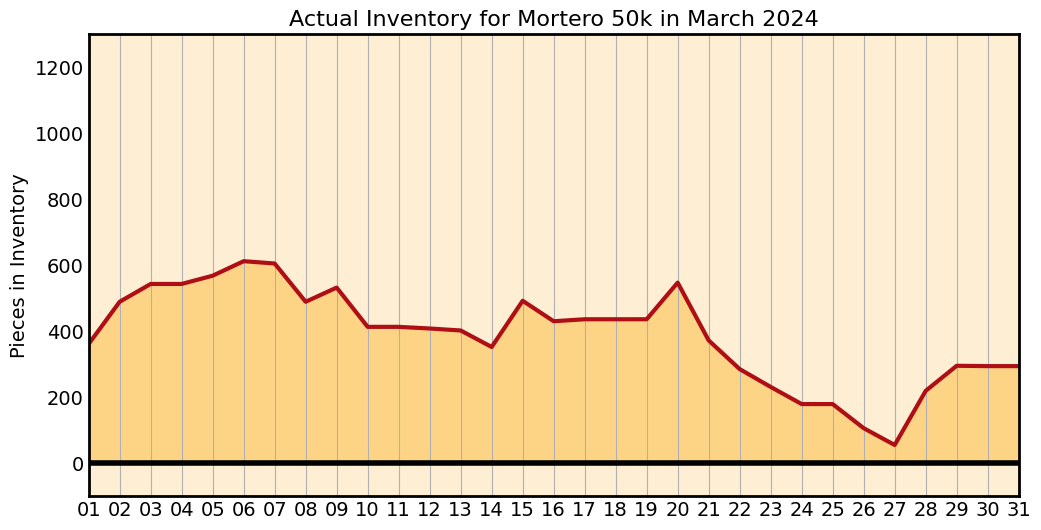

In [35]:
# prompt: for the graph of "Inventario", plot only for a month. I will input the month

month_input = "March" #@param ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
month_number = pd.to_datetime(month_input, format='%B').month
DpP_month = DpP[DpP['Date'].dt.month == month_number].copy()

plt.figure(figsize=(12, 6))
plt.gca().set_facecolor('#feefd4') # Light orange background

plt.plot(DpP_month['Date'], DpP_month['Inventario'], color='#af0f14', linewidth=3) # Red thick line
plt.fill_between(DpP_month['Date'], DpP_month['Inventario'], color='#fdd486', alpha=1) # Orange fill
plt.axhline(y=0, color='black', linestyle='-', linewidth=4)

plt.ylabel('Pieces in Inventory', fontsize=14)
plt.title(f'Actual Inventory for {description} in {month_input} 2024', fontsize=16)
plt.grid(axis='x')

# Set x-limits to the start and end of the selected month
start_date = pd.to_datetime(f'2024-{month_number}-01')
end_date = start_date + pd.offsets.MonthEnd(0)
plt.ylim(-100,1300)
plt.xlim(start_date, end_date)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=14) # Increase tick label size
ax.xaxis.set_major_locator(mdates.DayLocator()) # Set major ticks every 5 days
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d')) # Format ticks as day number
ax.tick_params(axis='both',        # apply to both axes
               which='both',       # apply to major *and* minor ticks
               length=0)
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.savefig(f'Actual_Inv_{description}_{month_input}.png', dpi=300, bbox_inches='tight')
plt.show()


In [10]:
lead_time = int(input("Enter the lead time (in days): "))
review_period = int(input("Enter the periodic review period (in days): "))
safety_stock = int(input("Enter the safety stock level: "))
target_inventory = int(input("Enter the target inventory level: "))

Enter the lead time (in days): 1
Enter the periodic review period (in days): 12
Enter the safety stock level: 563
Enter the target inventory level: 1185


In [31]:
current_inventory = DpP['Inventario'].iloc[0]

simulated_inventory = []
orders_placed = []
orders_received = []
inventory_on_order = 0
order_schedule = {}

for i in range(len(DpP)):
    # Step 5: Check if an order is expected to arrive on the current day
    current_date = DpP['Date'].iloc[i]
    if current_date in order_schedule:
        received_quantity = order_schedule.pop(current_date)
        current_inventory += received_quantity
        inventory_on_order -= received_quantity
        orders_received.append(received_quantity)
    else:
        orders_received.append(0)

    # Step 4: Update current_inventory by subtracting daily demand
    daily_demand = DpP['Demanda'].iloc[i]
    current_inventory -= daily_demand

    # Step 6 & 7: Check if the current day is a review day and calculate order quantity
    order_quantity = 0
    if i % review_period == 0: # Changed condition to start review on the first day
        order_quantity = target_inventory - current_inventory - inventory_on_order
        order_quantity = max(0, order_quantity) # Ensure order_quantity is not negative

    # Step 8: If an order is placed, record and schedule its arrival
    if order_quantity > 0:
        inventory_on_order += order_quantity
        arrival_date = current_date + pd.Timedelta(days=lead_time)
        order_schedule[arrival_date] = order_quantity
        orders_placed.append(order_quantity)
    else:
        orders_placed.append(0)

    # Step 9: Append the current_inventory to the list
    simulated_inventory.append(current_inventory)

# Step 10: Create a new DataFrame to store the simulation results
simulation_results_df = pd.DataFrame({
    'Date': DpP['Date'],
    'Inventory': simulated_inventory,
    'Orders Placed': orders_placed,
    'Orders Received': orders_received
})

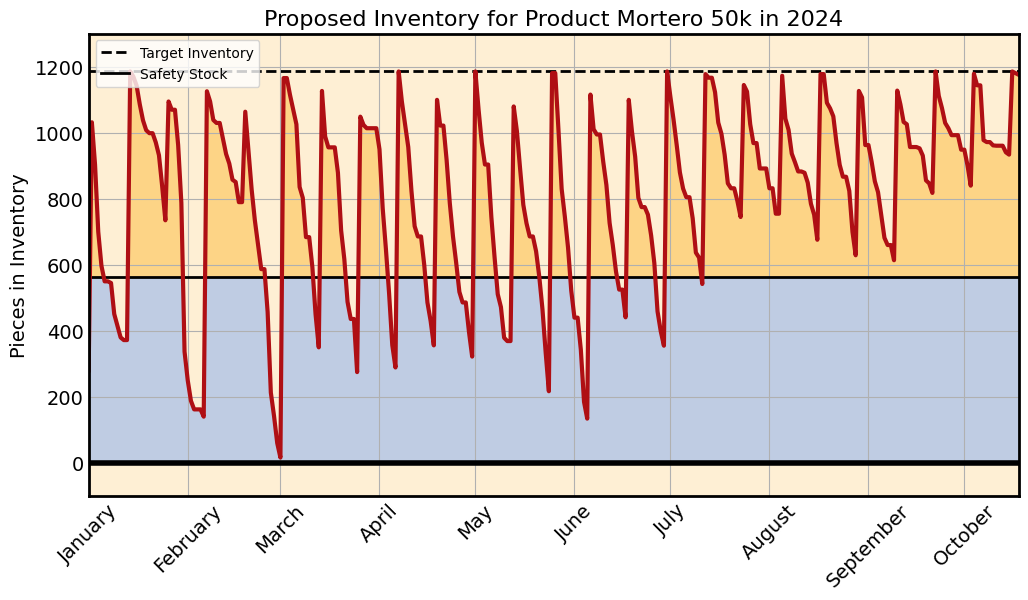

In [32]:
plt.figure(figsize=(12, 6))
plt.gca().set_facecolor('#feefd4')

# Fill between inventory and 0 when inventory is below safety stock
plt.fill_between(simulation_results_df['Date'], simulation_results_df['Inventory'], 0,
                 color='#bfcce3', alpha=1)
# Fill between inventory and safety stock when inventory is above safety stock
plt.fill_between(simulation_results_df['Date'], simulation_results_df['Inventory'], safety_stock,
                 where=(simulation_results_df['Inventory'] > safety_stock),
                 color='#fdd486', alpha=1)

plt.axhline(y=0, color='black', linestyle='-', linewidth=4)
plt.axhline(y=target_inventory, color='black', linestyle='--', linewidth=2, label='Target Inventory') # Add target inventory line
plt.axhline(y=safety_stock, color='black', linewidth=2, label='Safety Stock') # Add safety stock line

plt.plot(simulation_results_df['Date'], simulation_results_df['Inventory'], color='#af0f14', linewidth=3)

plt.ylabel('Pieces in Inventory', fontsize=14)
plt.title(f'Proposed Inventory for Product {description} in 2024', fontsize=16)

plt.grid(True)
plt.ylim(-100,1300)
plt.xlim(simulation_results_df['Date'].min(), simulation_results_df['Date'].max())
plt.xticks(rotation=45)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.tick_params(axis='both',
               which='both',
               length=0)
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.legend(loc='upper left') # Add legend to show the label for target inventory line
plt.savefig(f'Proposed_Inv_{description}.png', dpi=300, bbox_inches='tight')
plt.show()

## Final Simulated Inventory Data

In [17]:
# prompt: add the demand data to simulation_results_df
simulation_results_df['Demand'] = DpP['Demanda']
display(simulation_results_df.tail(10))

,Date,Inventory,Orders Placed,Orders Received,Demand
5360,2024-10-09,971,0,0,0
5361,2024-10-10,961,0,0,10
5362,2024-10-11,960,0,0,1
5363,2024-10-12,960,0,0,0
5364,2024-10-13,960,0,0,0
5365,2024-10-14,940,0,0,20
5366,2024-10-15,933,252,0,7
5367,2024-10-16,1185,0,252,0
5368,2024-10-17,1180,0,0,5
5369,2024-10-18,1175,0,0,5


In [33]:
month_to_plot = input("Enter the full name of the month you want to plot (e.g., January): ")
simulation_results_df['Date'] = pd.to_datetime(simulation_results_df['Date'])
monthly_simulation_df = simulation_results_df[simulation_results_df['Date'].dt.strftime('%B').str.lower() == month_to_plot.lower()]
display(monthly_simulation_df.head(10))

Enter the full name of the month you want to plot (e.g., January): March


,Date,Inventory,Orders Placed,Orders Received
3318,2024-03-01,15,1170,0
3319,2024-03-02,1165,0,1170
3320,2024-03-03,1165,0,0
3321,2024-03-04,1114,0,0
3322,2024-03-05,1070,0,0
3323,2024-03-06,1025,0,0
3324,2024-03-07,835,0,0
3325,2024-03-08,802,0,0
3326,2024-03-09,683,0,0
3327,2024-03-10,683,0,0


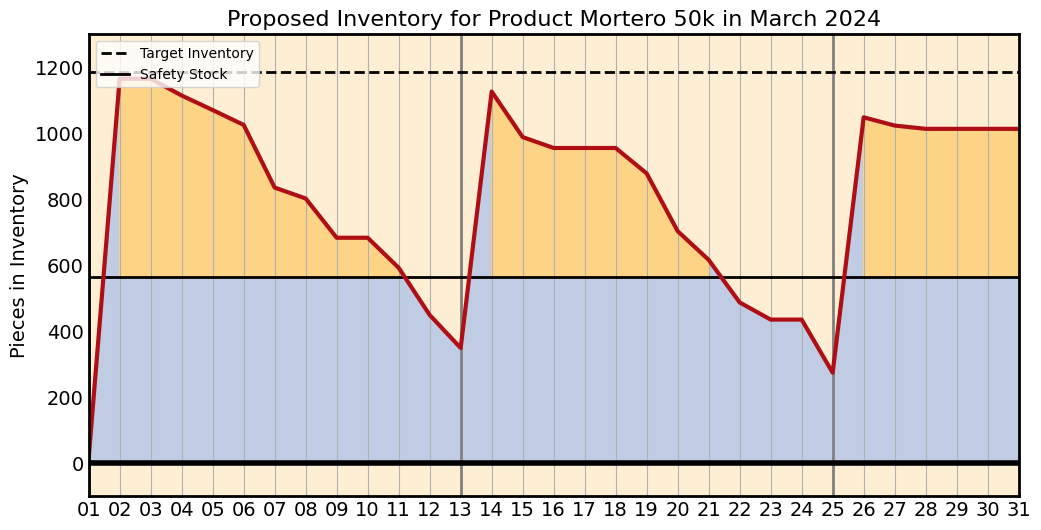

In [34]:
plt.figure(figsize=(12, 6))
plt.gca().set_facecolor('#feefd4')

# Fill between inventory and 0 when inventory is below safety stock
plt.fill_between(monthly_simulation_df['Date'], monthly_simulation_df['Inventory'], 0,
                 color='#bfcce3', alpha=1)
# Fill between inventory and safety stock when inventory is above safety stock
plt.fill_between(monthly_simulation_df['Date'], monthly_simulation_df['Inventory'], safety_stock,
                 where=(monthly_simulation_df['Inventory'] > safety_stock),
                 color='#fdd486', alpha=1)
# Fill between inventory when inventory is below 0 (backorders)
plt.fill_between(monthly_simulation_df['Date'], monthly_simulation_df['Inventory'], 0,
                 where=(monthly_simulation_df['Inventory'] < 0),
                 color='red', alpha=1)
# Add vertical lines for review days
for i in range(len(monthly_simulation_df)):
    if (i + monthly_simulation_df.index[0] -6) % review_period == 0:
        plt.axvline(x=monthly_simulation_df['Date'].iloc[i], color='gray', linestyle='-', linewidth=2)
plt.axhline(y=0, color='black', linestyle='-', linewidth=4)
plt.axhline(y=target_inventory, color='black', linestyle='--', linewidth=2, label='Target Inventory')
plt.axhline(y=safety_stock, color='black', linewidth=2, label='Safety Stock')

plt.plot(monthly_simulation_df['Date'], monthly_simulation_df['Inventory'], color='#af0f14', linewidth=3)

plt.ylabel('Pieces in Inventory', fontsize=14)
plt.title(f'Proposed Inventory for Product {description} in {month_to_plot.capitalize()} 2024', fontsize=16)

plt.grid(axis='x')
plt.ylim(-100,1300)
plt.xlim(monthly_simulation_df['Date'].min(), monthly_simulation_df['Date'].max())
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=14)
ax.xaxis.set_major_locator(mdates.DayLocator()) # Set major ticks to every day
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))
ax.tick_params(axis='both',
               which='both',
               length=0)
for spine in ax.spines.values():
    spine.set_linewidth(2)
plt.legend(loc='upper left')
plt.savefig(f'Proposed_Inv_{description}_{month_input}.png', dpi=300, bbox_inches='tight')
plt.show()